### 1. Mount Google Drive and Install Dependencies
We need to mount your drive to access the folder `BIOL 2595 Final Proj/ADNI dataset/`. We also install `monai` for medical image processing and `catboost` for clinical data.

In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')

# Define the base path for your dataset
dataset_path = '/content/drive/My Drive/BIOL 2595 Final Proj/ADNI dataset/'
print(f"Checking dataset path: {os.path.exists(dataset_path)}")

!pip install -q monai catboost nibabel

Mounted at /content/drive
Checking dataset path: True
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 92.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 27.9 MB/s eta 0:00:00


### 2. Organize Project Structure
We will create specific directories for models, results, training scripts, and utilities to maintain a professional project workflow.

In [2]:
import os

# Define the root project path
project_root = '/content/drive/My Drive/BIOL 2595 Final Proj/'

# List of sub-directories to ensure exist
sub_dirs = ['models', 'results', 'train', 'utils']

print("Ensuring project structure is in place...")
for folder in sub_dirs:
    path = os.path.join(project_root, folder)
    if not os.path.exists(path):
        os.makedirs(path)
        print(f"Created: {folder}/")
    else:
        print(f"Exists: {folder}/")

print("\nProject structure validated.")

Ensuring project structure is in place...
Exists: models/
Exists: results/
Exists: train/
Exists: utils/

Project structure validated.


### 2. Data Preparation Pipeline
This section defines how we handle the MRI (.nii) files and the clinical data alignment.

In [3]:
import sys
!pip install -q monai
import nibabel as nib
import numpy as np
import pandas as pd
from monai.transforms import (Compose, LoadImaged, EnsureChannelFirstd, Resized, ScaleIntensityd, ToTensord)

# Updated template for MRI Preprocessing: Use Resized to scale the whole brain instead of cropping
mri_transforms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    ScaleIntensityd(keys=["image"]),
    Resized(keys=["image"], spatial_size=(128, 128, 128)),
    ToTensord(keys=["image"])
])

def preprocess_clinical_data(df):
    df = df.fillna(df.median(numeric_only=True))
    return df

print("Preprocessing pipeline updated with Resized.")

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


Preprocessing pipeline updated with Resized.


### 3. Model Architecture: Multimodal Fusion
We will use a Swin Transformer for the MRI branch and a CatBoost/Feature extractor for the clinical branch, then fuse them.

In [4]:
import torch
import torch.nn as nn
from monai.networks.nets import SwinUNETR

class MultimodalFusionModel(nn.Module):
    def __init__(self, num_clinical_features, num_classes=3):
        super(MultimodalFusionModel, self).__init__()
        # MRI Branch: Swin Transformer (using encoder portion)
        self.mri_branch = SwinUNETR(img_size=(128, 128, 128), in_channels=1, out_channels=num_classes, feature_size=48)

        # Clinical Branch: Simple MLP to mirror CatBoost features if training end-to-end
        # Or use CatBoost separately and fuse scores.
        self.clinical_branch = nn.Sequential(
            nn.Linear(num_clinical_features, 64),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        # Fusion Layer
        self.fusion = nn.Linear(48 + 64, num_classes) # Adjust 48 based on Swin output

    def forward(self, mri, clinical):
        mri_feat = self.mri_branch(mri)
        cli_feat = self.clinical_branch(clinical)
        combined = torch.cat((mri_feat, cli_feat), dim=1)
        return self.fusion(combined)

print("Multimodal Model Skeleton created.")

Multimodal Model Skeleton created.


### 4. Generate Table 1: Clinical Data Summary
Following your logic to calculate ratios and summarize demographics from the clinical CSV files.

In [5]:
import pandas as pd
import numpy as np
import os

# Paths
clinical_root = os.path.join(dataset_path, 'Clinical_data')
n_psych_root = os.path.join(clinical_root, 'Neuropsychological')
demog_root = os.path.join(clinical_root, 'Subject_Demographics')

def choose_numeric_col(df, preferred_names):
    for col in preferred_names:
        if col in df.columns: return col
    return None

def normalize_baseline_visits(df):
    if 'RID' not in df.columns: return df
    vis_col = next((c for c in ['VISCODE2', 'VISCODE', 'Timepoint'] if c in df.columns), None)
    if vis_col:
        df['VISIT_KEY'] = df[vis_col].astype(str).str.strip().str.lower()
        baseline_tags = {'bl', 'sc', 'scmri', 'init', 'm0'}
        is_baseline = df['VISIT_KEY'].isin(baseline_tags)
        if is_baseline.any():
            return df[is_baseline].sort_values('RID').drop_duplicates('RID')
    return df.sort_values('RID').drop_duplicates('RID')

# 1. Load Data
dx_df = normalize_baseline_visits(pd.read_csv(os.path.join(clinical_root, 'DXSUM_06Apr2026.csv'), low_memory=False))
demog_df = normalize_baseline_visits(pd.read_csv(os.path.join(demog_root, 'PTDEMOG_06Apr2026.csv'), low_memory=False))
mmse = normalize_baseline_visits(pd.read_csv(os.path.join(n_psych_root, 'MMSE_06Apr2026.csv'), low_memory=False))
adas = normalize_baseline_visits(pd.read_csv(os.path.join(n_psych_root, 'ADAS_06Apr2026.csv'), low_memory=False))
cdr = normalize_baseline_visits(pd.read_csv(os.path.join(n_psych_root, 'CDR_06Apr2026.csv'), low_memory=False))
faq = normalize_baseline_visits(pd.read_csv(os.path.join(n_psych_root, 'FAQ_06Apr2026.csv'), low_memory=False))
gds = normalize_baseline_visits(pd.read_csv(os.path.join(n_psych_root, 'GDSCALE_06Apr2026.csv'), low_memory=False))
npiq = normalize_baseline_visits(pd.read_csv(os.path.join(n_psych_root, 'NPIQ_06Apr2026.csv'), low_memory=False))

# 2. Process Variables
def recode_diagnosis(val):
    s = str(val).strip().lower()
    if s in {'1', '1.0', 'cn', 'normal'}: return 'Normal'
    if s in {'2', '2.0'} or 'mci' in s: return 'MCI'
    if s in {'3', '3.0'} or 'ad' in s or 'dementia' in s: return 'AD'
    return np.nan

dx_df['DX_GROUP'] = dx_df['DIAGNOSIS'].apply(recode_diagnosis)

demog_df['VISDATE'] = pd.to_datetime(demog_df['USERDATE'], errors='coerce')
demog_df['PTDOB'] = pd.to_datetime(demog_df['PTDOB'], errors='coerce')
demog_df['AGE'] = (demog_df['VISDATE'] - demog_df['PTDOB']).dt.days / 365.25
demog_df['FEMALE'] = (demog_df['PTGENDER'] == 2).astype(float)

# Fixed Race Mapping logic
race_map = {'1': 'Am. Indian', '2': 'Asian', '3': 'Hawaiian', '4': 'Black', '5': 'White', '6': 'Mixed', '7': 'Unknown'}
def map_race(val):
    if pd.isna(val): return 'Unknown'
    primary_code = str(val).split('|')[0] # Handle multi-coded entries like '4|5'
    return race_map.get(primary_code, 'Unknown')

demog_df['RACE_LABEL'] = demog_df['PTRACCAT'].apply(map_race)

# Scores
mmse_col = choose_numeric_col(mmse, ['MMSCORE', 'MMSE', 'TOTSCORE'])
mmse['MMSE_VAL'] = pd.to_numeric(mmse[mmse_col], errors='coerce') if mmse_col else np.nan
adas_col = choose_numeric_col(adas, ['TOTAL11', 'TOTSCORE', 'ADAS11'])
adas['ADAS_VAL'] = pd.to_numeric(adas[adas_col], errors='coerce') if adas_col else np.nan
cdr['CDR_SB_VAL'] = pd.to_numeric(cdr['CDRSB'], errors='coerce')
cdr['CDR_GL_VAL'] = pd.to_numeric(cdr['CDGLOBAL'], errors='coerce')
faq_col = choose_numeric_col(faq, ['FAQTOTAL', 'TOTAL'])
faq['FAQ_VAL'] = pd.to_numeric(faq[faq_col], errors='coerce') if faq_col else np.nan
gds_col = choose_numeric_col(gds, ['GDTOTAL', 'GDSCORE'])
gds['GDS_VAL'] = pd.to_numeric(gds[gds_col], errors='coerce') if gds_col else np.nan
npiq['NPIQ_VAL'] = pd.to_numeric(npiq['NPISCORE'], errors='coerce')
npiq['ANXIETY'] = (pd.to_numeric(npiq['NPIJ'], errors='coerce') > 0).astype(float)
npiq['AGITATION'] = (pd.to_numeric(npiq['NPIA'], errors='coerce') > 0).astype(float)

# 3. Merge
merged = dx_df[['RID', 'DX_GROUP']].dropna()
for df, cols in [(demog_df, ['RID','AGE','FEMALE','PTEDUCAT','RACE_LABEL']),
                 (mmse, ['RID','MMSE_VAL']), (adas, ['RID','ADAS_VAL']),
                 (cdr, ['RID','CDR_SB_VAL','CDR_GL_VAL']), (faq, ['RID','FAQ_VAL']),
                 (gds, ['RID','GDS_VAL']), (npiq, ['RID','NPIQ_VAL','ANXIETY','AGITATION'])]:
    merged = merged.merge(df[cols], on='RID', how='left')

merged['MISSING_PCT'] = merged.isnull().mean(axis=1) * 100

# 4. Summarize
def get_stats(sub):
    if len(sub) == 0: return {'N': 0}
    res = {'N': len(sub)}
    res['Age'] = f"{sub['AGE'].mean():.1f} ± {sub['AGE'].std():.1f}"
    res['Female, n (%)'] = f"{(sub['FEMALE']==1).sum()} ({(sub['FEMALE']==1).mean()*100:.1f}%)"
    res['Education'] = f"{sub['PTEDUCAT'].mean():.1f} ± {sub['PTEDUCAT'].std():.1f}"
    res['Race (Top)'] = sub['RACE_LABEL'].mode()[0] if not sub['RACE_LABEL'].mode().empty else "N/A"
    res['MMSE'] = f"{sub['MMSE_VAL'].mean():.1f} ± {sub['MMSE_VAL'].std():.1f}"
    res['ADAS-11'] = f"{sub['ADAS_VAL'].mean():.1f} ± {sub['ADAS_VAL'].std():.1f}"
    res['CDR Global'] = f"{sub['CDR_GL_VAL'].mean():.1f} ± {sub['CDR_GL_VAL'].std():.1f}"
    res['CDR-SB'] = f"{sub['CDR_SB_VAL'].mean():.1f} ± {sub['CDR_SB_VAL'].std():.1f}"
    res['FAQ'] = f"{sub['FAQ_VAL'].mean():.1f} ± {sub['FAQ_VAL'].std():.1f}"
    res['GDS'] = f"{sub['GDS_VAL'].mean():.1f} ± {sub['GDS_VAL'].std():.1f}"
    res['NPIQ Total'] = f"{sub['NPIQ_VAL'].mean():.1f} ± {sub['NPIQ_VAL'].std():.1f}"
    res['Anxiety (%)'] = f"{(sub['ANXIETY']==1).mean()*100:.1f}%"
    res['Agitation (%)'] = f"{(sub['AGITATION']==1).mean()*100:.1f}%"
    res['Missing (%)'] = f"{sub['MISSING_PCT'].mean():.1f}%"
    return res

t1 = pd.DataFrame({'Total': get_stats(merged),
                   'Normal': get_stats(merged[merged['DX_GROUP']=='Normal']),
                   'MCI': get_stats(merged[merged['DX_GROUP']=='MCI']),
                   'AD': get_stats(merged[merged['DX_GROUP']=='AD'])})
display(t1)

/tmp/ipykernel_7884/3896486407.py:47: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  demog_df['PTDOB'] = pd.to_datetime(demog_df['PTDOB'], errors='coerce')


,Total,Normal,MCI,AD
N,3697,1588,1551,558
Age,72.1 ± 7.8,70.6 ± 7.3,72.7 ± 7.8,74.7 ± 7.9
"Female, n (%)",1901 (51.4%),979 (61.6%),678 (43.7%),244 (43.7%)
Education,16.1 ± 2.8,16.5 ± 2.5,16.0 ± 2.8,15.2 ± 3.0
Race (Top),White,White,White,White
MMSE,27.5 ± 2.7,29.0 ± 1.2,27.5 ± 2.0,23.0 ± 2.8
ADAS-11,9.8 ± 6.4,5.7 ± 2.9,10.1 ± 4.5,19.5 ± 6.8
CDR Global,0.3 ± 0.3,0.0 ± 0.1,0.5 ± 0.1,0.8 ± 0.3
CDR-SB,1.3 ± 1.8,0.1 ± 0.2,1.5 ± 1.0,4.5 ± 1.8
FAQ,3.6 ± 5.9,0.2 ± 0.9,3.2 ± 4.2,13.2 ± 6.9


In [6]:
# Inspect the 'PTRACCAT' column to debug the N/A race labels
print("Unique values in PTRACCAT (Raw):")
print(demog_df['PTRACCAT'].unique())

print("\nValue counts for PTRACCAT:")
print(demog_df['PTRACCAT'].value_counts(dropna=False))

# Check the data type to ensure mapping works (e.g., int vs str)
print(f"\nData type of PTRACCAT: {demog_df['PTRACCAT'].dtype}")

Unique values in PTRACCAT (Raw):
['5' '6' '4' '2' '-4' '7' '1' nan '3' '4|5' '1|5' '2|5' '3|4|5' '1|4'
 '1|7' '1|4|5' '2|4' '9' '5|8' '8']

Value counts for PTRACCAT:
PTRACCAT
5        3492
4         507
2         143
7          49
6          45
1          13
NaN        12
1|5        10
2|5         7
4|5         5
3           4
-4          3
1|4         3
2|4         3
9           2
1|4|5       2
1|7         1
3|4|5       1
5|8         1
8           1
Name: count, dtype: int64

Data type of PTRACCAT: object


### 5. Explore Dataset Structure (Skipped)
*This step was skipped to save time during re-runs.*

In [7]:
# import os
#
# def list_files(startpath):
#     ...
#
# list_files(dataset_path)

print('Dataset exploration skipped.')

Dataset exploration skipped.


In [8]:
import zipfile
import os

# Path to the zip file on your Google Drive
zip_path = '/content/drive/MyDrive/BIOL 2595 Final Proj/ADNI dataset/ADNI1_Complete 3Yr 1.5T.zip'
# Path to extract to on the fast local Colab disk
extract_path = '/content/ADNI_3Yr_Extracted/'

if not os.path.exists(extract_path):
    print(f"Extracting {zip_path} to {extract_path}... This should only take a few seconds.")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("\u2705 Extraction complete!")
else:
    print("\u2705 Files already extracted!")

Extracting /content/drive/MyDrive/BIOL 2595 Final Proj/ADNI dataset/ADNI1_Complete 3Yr 1.5T.zip to /content/ADNI_3Yr_Extracted/... This should only take a few seconds.
✅ Extraction complete!


In [9]:
# Step 4: Map MRI Paths (Updated for Local 3Yr Extracted Dataset)
import os
import glob
import pandas as pd

def map_mri_paths(target_rids):
    """
    Specifically targets the nested ADNI directory structure to find .nii files.
    """
    mri_mapping = []
    target_rids_set = set(target_rids)

    # Updated to point to the newly extracted LOCAL folder:
    mri_root = '/content/ADNI_3Yr_Extracted/ADNI/'

    print(f"Searching for MRI files in: {mri_root}")

    if not os.path.exists(mri_root):
        print(f"Warning: Path not found: {mri_root}")
        return pd.DataFrame(columns=['RID', 'mri_path'])

    # List subject folders (e.g., 002_S_0413)
    for subject_folder in os.listdir(mri_root):
        if '_' in subject_folder:
            parts = subject_folder.split('_')
            rid_str = parts[-1].lstrip('0')
            if rid_str == '': rid_str = '0'

            if rid_str.isdigit():
                rid_int = int(rid_str)
                if rid_int in target_rids_set:
                    subject_path = os.path.join(mri_root, subject_folder)
                    # Recursive search for .nii files
                    nii_files = glob.glob(os.path.join(subject_path, "**/*.nii"), recursive=True)
                    if nii_files:
                        mri_mapping.append({'RID': rid_int, 'mri_path': nii_files[0]})

    df = pd.DataFrame(mri_mapping)
    if not df.empty:
        df = df.drop_duplicates(subset=['RID'])
    return df if not df.empty else pd.DataFrame(columns=['RID', 'mri_path'])

# Get target RIDs from the clinical merged data
target_rids = merged['RID'].unique()

# Perform alignment using the new local paths
mri_path_df = map_mri_paths(target_rids)

if not mri_path_df.empty:
    final_dataset = merged.merge(mri_path_df, on='RID', how='inner')
    print(f"Successfully aligned {len(final_dataset)} subjects with both clinical and MRI data.")
    display(final_dataset[['RID', 'DX_GROUP', 'mri_path']].head())
else:
    print("Alignment failed. Please check if the .nii files are actually present in the 'ADNI' subfolders.")
    final_dataset = pd.DataFrame()

Searching for MRI files in: /content/ADNI_3Yr_Extracted/ADNI/
Successfully aligned 382 subjects with both clinical and MRI data.


,RID,DX_GROUP,mri_path
0,3,AD,/content/ADNI_3Yr_Extracted/ADNI/011_S_0003/MP...
1,5,Normal,/content/ADNI_3Yr_Extracted/ADNI/011_S_0005/MP...
2,10,AD,/content/ADNI_3Yr_Extracted/ADNI/011_S_0010/MP...
3,14,Normal,/content/ADNI_3Yr_Extracted/ADNI/022_S_0014/MP...
4,16,Normal,/content/ADNI_3Yr_Extracted/ADNI/011_S_0016/MP...


In [10]:
import os

extract_path = '/content/ADNI_3Yr_Extracted/'
print(f"Contents of {extract_path}:")
if os.path.exists(extract_path):
    print(os.listdir(extract_path))

    adni_folder = os.path.join(extract_path, 'ADNI')
    if os.path.exists(adni_folder):
        print(f"\nContents of {adni_folder} (first 10 items):")
        print(os.listdir(adni_folder)[:10])
else:
    print("Path does not exist!")

Contents of /content/ADNI_3Yr_Extracted/:
['ADNI']

Contents of /content/ADNI_3Yr_Extracted/ADNI (first 10 items):
['116_S_0649', '137_S_0796', '114_S_0173', '094_S_1267', '027_S_0116', '002_S_0619', '136_S_0299', '021_S_1109', '014_S_0519', '123_S_0094']


### 6. Multimodal Dataset and DataLoader
We define a custom PyTorch dataset that returns both the preprocessed 3D MRI volume and the clinical feature vector.

In [11]:
from torch.utils.data import Dataset, DataLoader

class MultimodalDataset(Dataset):
    def __init__(self, df, transforms):
        self.df = df
        self.transforms = transforms
        # Encode labels: Normal=0, MCI=1, AD=2
        self.label_map = {'Normal': 0, 'MCI': 1, 'AD': 2}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_data = {"image": row['mri_path']}
        preprocessed = self.transforms(image_data)

        # Clinical features (using a subset for demo)
        clinical_tensor = torch.tensor([
            row['AGE'], row['FEMALE'], row['PTEDUCAT'], row['MMSE_VAL']
        ], dtype=torch.float32)

        label = torch.tensor(self.label_map[row['DX_GROUP']], dtype=torch.long)

        return preprocessed['image'], clinical_tensor, label

# Initialize Dataset
test_ds = MultimodalDataset(final_dataset, mri_transforms)

# Safely initialize DataLoader only if there are samples
if len(test_ds) > 0:
    test_loader = DataLoader(test_ds, batch_size=4, shuffle=True)
    print(f"DataLoader initialized with {len(test_ds)} samples.")
else:
    print("Warning: final_dataset is empty! Cannot initialize DataLoader with 0 samples.")
    print("Please check the previous steps to ensure the MRI files are extracted correctly.")


DataLoader initialized with 382 samples.


### 7. Label Distribution
Checking the balance of our classes in the final aligned dataset.

/tmp/ipykernel_7884/1115557335.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=final_dataset, x='DX_GROUP', palette='viridis', order=['Normal', 'MCI', 'AD'])


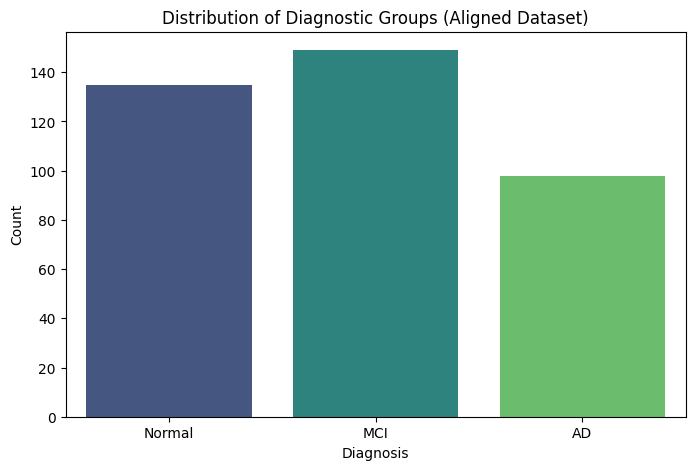

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(data=final_dataset, x='DX_GROUP', palette='viridis', order=['Normal', 'MCI', 'AD'])
plt.title('Distribution of Diagnostic Groups (Aligned Dataset)')
plt.ylabel('Count')
plt.xlabel('Diagnosis')
plt.show()

### 8. MRI Visualization (10 Samples)
Visualizing the central axial slice of 10 MRI volumes after preprocessing.

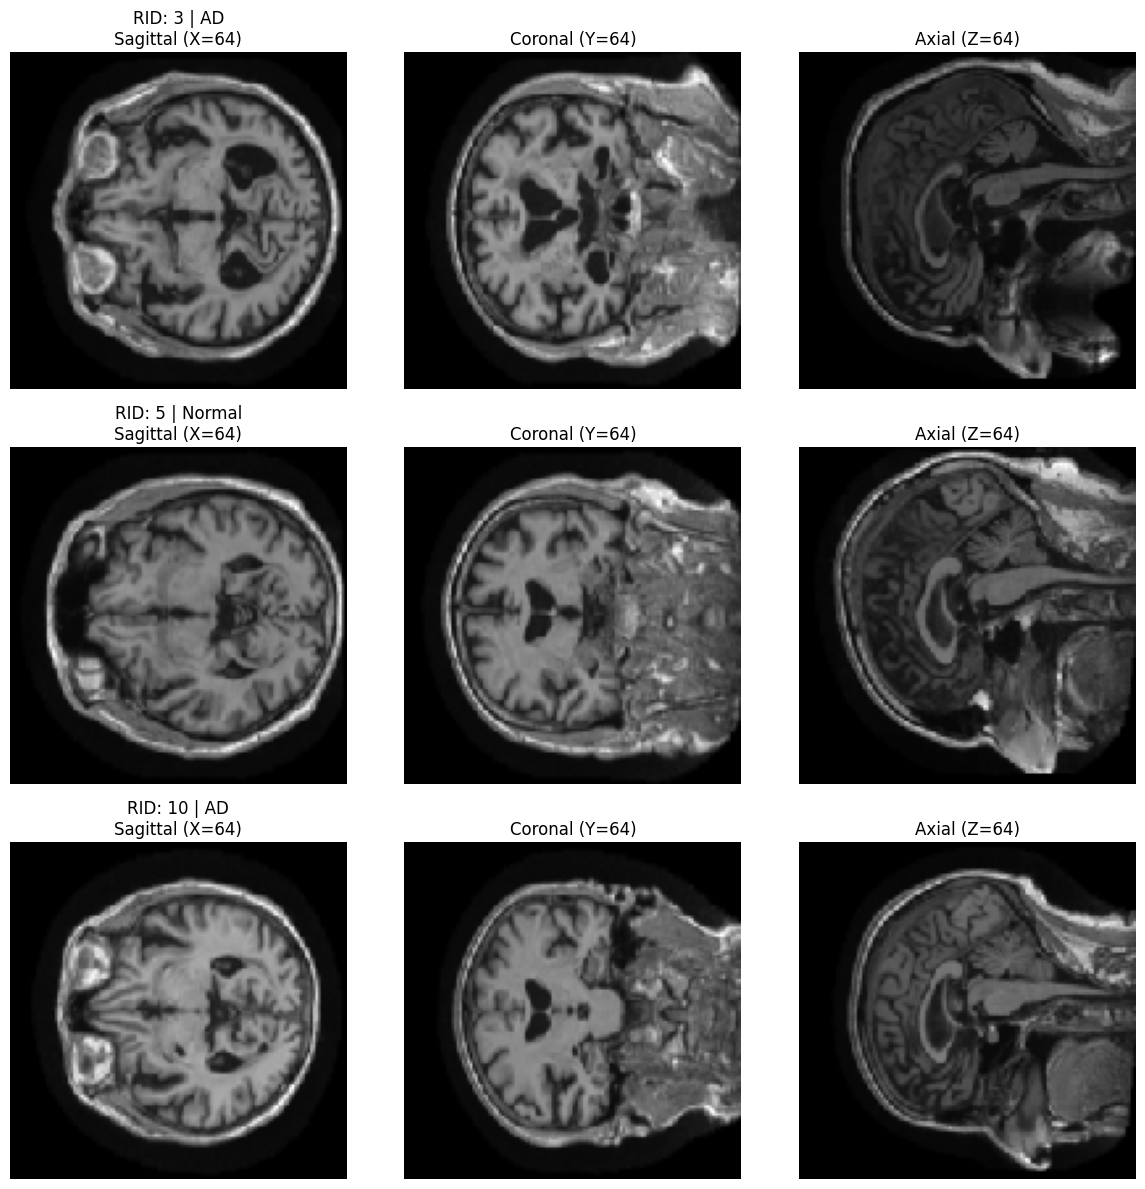

In [13]:
import torch
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

# Redefine the dataset class in case the cell above wasn't run after a restart
class MultimodalDataset(Dataset):
    def __init__(self, df, transforms):
        self.df = df
        self.transforms = transforms
        self.label_map = {'Normal': 0, 'MCI': 1, 'AD': 2}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_data = {"image": row['mri_path']}
        preprocessed = self.transforms(image_data)

        clinical_tensor = torch.tensor([
            row['AGE'], row['FEMALE'], row['PTEDUCAT'], row.get('MMSE_VAL', 0)
        ], dtype=torch.float32)

        label = torch.tensor(self.label_map[row['DX_GROUP']], dtype=torch.long)

        return preprocessed['image'], clinical_tensor, label

# Re-initialize dataset with updated transforms to apply the Resized fix
test_ds = MultimodalDataset(final_dataset, mri_transforms)

# Let's visualize the 3 orthographic planes for the first 3 patients
num_patients = 3
fig, axes = plt.subplots(num_patients, 3, figsize=(12, 4 * num_patients))

for i in range(num_patients):
    img, clinical, label = test_ds[i]
    # Convert from (C, H, W, D) to numpy array. Volume is 128x128x128.
    volume = img[0].numpy()

    # Find the middle index of each dimension
    mid_x = volume.shape[0] // 2
    mid_y = volume.shape[1] // 2
    mid_z = volume.shape[2] // 2

    # Extract the 3 orthogonal slices
    slice_sagittal = volume[mid_x, :, :]
    slice_coronal = volume[:, mid_y, :]
    slice_axial = volume[:, :, mid_z]

    patient_info = f"RID: {final_dataset.iloc[i]['RID']} | {final_dataset.iloc[i]['DX_GROUP']}"

    # Plot Sagittal
    axes[i, 0].imshow(slice_sagittal.T, cmap='gray', origin='lower') # .T and origin='lower' to fix orientation
    axes[i, 0].set_title(f"{patient_info}\nSagittal (X={mid_x})")
    axes[i, 0].axis('off')

    # Plot Coronal
    axes[i, 1].imshow(slice_coronal.T, cmap='gray', origin='lower')
    axes[i, 1].set_title(f"Coronal (Y={mid_y})")
    axes[i, 1].axis('off')

    # Plot Axial
    axes[i, 2].imshow(slice_axial.T, cmap='gray', origin='lower')
    axes[i, 2].set_title(f"Axial (Z={mid_z})")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

In [14]:
# Iterate through the DataLoader to verify all samples load correctly without errors
print("Testing DataLoader...")
total_samples = 0

try:
    for batch_idx, (mri_batch, clinical_batch, label_batch) in enumerate(test_loader):
        total_samples += mri_batch.size(0)

        # Print the shape of the tensors in the first batch for sanity check
        if batch_idx == 0:
            print(f"First batch MRI shape: {mri_batch.shape} (Batch, Channel, D, H, W)")
            print(f"First batch Clinical shape: {clinical_batch.shape}")
            print(f"First batch Label shape: {label_batch.shape}\n")

    print(f"Successfully loaded {total_samples} samples!")

    if total_samples == len(test_ds):
        print("\u2705 All samples were processed successfully!")
    else:
        print(f"\u26a0\ufe0f Warning: Expected {len(test_ds)} samples, but only loaded {total_samples}.")

except Exception as e:
    print(f"\n\u274c An error occurred while loading a sample: {e}")
    print(f"Number of samples successfully loaded before error: {total_samples}")

Testing DataLoader...
First batch MRI shape: torch.Size([4, 1, 128, 128, 128]) (Batch, Channel, D, H, W)
First batch Clinical shape: torch.Size([4, 4])
First batch Label shape: torch.Size([4])

Successfully loaded 382 samples!
✅ All samples were processed successfully!


In [54]:
# Step 1: MRI Data Augmentation Pipeline
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Resized, ScaleIntensityd,
    ToTensord, RandRotate90d, RandFlipd, RandAffined, CropForegroundd
)

# Training transforms include data augmentation to prevent overfitting
mri_train_transforms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    ScaleIntensityd(keys=["image"]),
    # Crop the empty black background out to force the model to look at the brain
    CropForegroundd(keys=["image"], source_key="image"),
    Resized(keys=["image"], spatial_size=(128, 128, 128)),
    RandRotate90d(keys=["image"], prob=0.5, spatial_axes=(0, 2)),
    RandFlipd(keys=["image"], prob=0.5, spatial_axis=0),
    RandAffined(keys=["image"], prob=0.3, translate_range=5),
    ToTensord(keys=["image"])
])

# Validation/Test transforms only resize and scale
mri_val_transforms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    ScaleIntensityd(keys=["image"]),
    # Ensure we evaluate on cropped brain as well
    CropForegroundd(keys=["image"], source_key="image"),
    Resized(keys=["image"], spatial_size=(128, 128, 128)),
    ToTensord(keys=["image"])
])

print("MRI Data Augmentation pipelines configured with CropForegroundd.")

MRI Data Augmentation pipelines configured with CropForegroundd.


In [16]:
# Step 2: Clinical Data Prep and CatBoost Setup
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define the clinical features we want to use
clin_features = ['AGE', 'FEMALE', 'PTEDUCAT', 'MMSE_VAL', 'ADAS_VAL', 'CDR_SB_VAL', 'FAQ_VAL', 'GDS_VAL']
clin_df = merged.dropna(subset=['DX_GROUP']).copy()

# Handle missing values (Median imputation for numerical variables)
for col in clin_features:
    clin_df[col] = clin_df[col].fillna(clin_df[col].median())

# Encode labels
label_map = {'Normal': 0, 'MCI': 1, 'AD': 2}
clin_df['label'] = clin_df['DX_GROUP'].map(label_map)

# Normalize clinical variables using StandardScaler
scaler = StandardScaler()
clin_df[clin_features] = scaler.fit_transform(clin_df[clin_features])

# Patient-level split for Clinical Model
X_clin = clin_df[clin_features]
y_clin = clin_df['label']

X_train_c, X_val_c, y_train_c, y_val_c = train_test_split(
    X_clin, y_clin, test_size=0.2, random_state=42, stratify=y_clin
)

# Initialize CatBoost with hyperparameters ready for tuning
catboost_model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    l2_leaf_reg=3, # Regularization/weight decay equivalent
    loss_function='MultiClass',
    custom_metric=['Accuracy'],
    auto_class_weights='Balanced', # Handle class imbalances
    verbose=100
)

print(f"CatBoost pipeline ready. Training samples: {len(X_train_c)}, Validation samples: {len(X_val_c)}")

CatBoost pipeline ready. Training samples: 2957, Validation samples: 740


### 9. MRI Model Training (Swin Transformer)
First, we split our 382 aligned subjects into training and validation sets for the PyTorch DataLoaders.

In [55]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, WeightedRandomSampler
import torch

# Split the 382 multimodal aligned subjects
train_df, val_df = train_test_split(
    final_dataset, test_size=0.2, random_state=42, stratify=final_dataset['DX_GROUP']
)

# Create Datasets with the correct transforms (Augmentation for train, simple resize for val)
train_ds = MultimodalDataset(train_df, mri_train_transforms)
val_ds = MultimodalDataset(val_df, mri_val_transforms)

# --- Fix: Weighted Random Sampler ---
# This forces the dataloader to oversample AD/Normal and undersample MCI to achieve perfectly balanced batches.
class_counts = train_df['DX_GROUP'].value_counts()
class_weights_sampler = 1.0 / class_counts
sample_weights = [class_weights_sampler[row['DX_GROUP']] for _, row in train_df.iterrows()]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# Create DataLoaders
# Set batch_size=1 to save memory. Shuffle must be False when using a sampler.
train_loader = DataLoader(train_ds, batch_size=1, sampler=sampler, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=2)

print(f"MRI DataLoaders ready. Training samples: {len(train_ds)} | Validation samples: {len(val_ds)}")

MRI DataLoaders ready. Training samples: 305 | Validation samples: 77


In [46]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from monai.networks.nets import resnet18
from tqdm.notebook import tqdm
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# --- 1. Combined Loss Function ---
class CombinedLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, label_smoothing=0.1):
        super(CombinedLoss, self).__init__()
        self.weight = weight
        self.gamma = gamma
        # Standard Cross Entropy with Label Smoothing
        self.ce = nn.CrossEntropyLoss(weight=weight, label_smoothing=label_smoothing)

    def forward(self, inputs, targets):
        # 1. Calculate standard CE Loss
        ce_loss = self.ce(inputs, targets)

        # 2. Calculate Focal Loss Component
        ce_loss_raw = F.cross_entropy(inputs, targets, weight=self.weight, reduction='none')
        pt = torch.exp(-F.cross_entropy(inputs, targets, reduction='none')) # prob of true class
        focal_loss = (((1 - pt) ** self.gamma) * ce_loss_raw).mean()

        # 3. Combine them (Weighted CE + 0.5 * Focal)
        return ce_loss + 0.5 * focal_loss

# --- 2. Fix Normalization for Batch Size 1 ---
def replace_bn_with_in(module):
    """
    Batch size of 1 breaks BatchNorm3d. We replace all BatchNorm3d layers
    with InstanceNorm3d, which computes statistics per channel per sample.
    """
    for name, child in module.named_children():
        if isinstance(child, nn.BatchNorm3d):
            # Replace with InstanceNorm3d
            setattr(module, name, nn.InstanceNorm3d(child.num_features, affine=True))
        else:
            # Recursively apply to child modules
            replace_bn_with_in(child)

# --- Model & Training Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Calculate dynamic class weights based on train_df
train_labels = [train_ds.label_map[row['DX_GROUP']] for _, row in train_df.iterrows()]
class_weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)

# Soften the weights slightly so we don't over-penalize the majority classes
class_weights = np.power(class_weights, 0.5)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(f"Computed Class Weights (Normal, MCI, AD): {class_weights_tensor.cpu().numpy()}")

# Initialize a 3D ResNet-18
mri_model = resnet18(spatial_dims=3, n_input_channels=1, num_classes=3).to(device)

# Apply the InstanceNorm fix
replace_bn_with_in(mri_model)
print("Replaced BatchNorm3d with InstanceNorm3d to properly support batch_size=1.")

# Use our new Combined Loss
criterion = CombinedLoss(weight=class_weights_tensor, gamma=2.0, label_smoothing=0.1)

# Optimizer with increased L2 Regularization (weight_decay=1e-2) to discourage background focus
optimizer = optim.Adam(mri_model.parameters(), lr=1e-4, weight_decay=1e-2)

# Epochs & Scheduler
num_epochs = 100
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)


Using device: cuda
Computed Class Weights (Normal, MCI, AD): [0.97023606 0.9243061  1.1416737 ]
Replaced BatchNorm3d with InstanceNorm3d to properly support batch_size=1.


In [47]:
import gc
import torch

# Look for leftover large variables in the global namespace and delete them
vars_to_delete = ['mri', 'clin', 'labels', 'outputs', 'loss', 'sample_mri', 'saliency_map', 'original_img', 'mri_batch']
for var in vars_to_delete:
    if var in globals():
        del globals()[var]

# Force Python to garbage collect unreferenced objects
gc.collect()

# Now empty the PyTorch cache
torch.cuda.empty_cache()

# Print current GPU memory usage to confirm it is clean
allocated = torch.cuda.memory_allocated() / 1024**3
reserved = torch.cuda.memory_reserved() / 1024**3
print(f"GPU Memory Allocated: {allocated:.2f} GB")
print(f"GPU Memory Reserved:  {reserved:.2f} GB")
print("If allocated memory is still very high (e.g., > 2GB), please Restart the Colab Session.")

GPU Memory Allocated: 1.08 GB
GPU Memory Reserved:  7.56 GB
If allocated memory is still very high (e.g., > 2GB), please Restart the Colab Session.


In [ ]:
import os
import torch
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

torch.cuda.empty_cache()  # Clear memory before training

# Move model to device
mri_model = mri_model.to(device)

print("Starting MRI Model Training with Gradient Accumulation (Simulated Batch Size = 8)...")

# Tracking metrics for plotting
train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_val_acc = 0.0
checkpoint_dir = '/content/drive/My Drive/BIOL 2595 Final Proj/models'
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_path = os.path.join(checkpoint_dir, 'best_mri_swin_model.pth')

# Initialize GradScaler for Mixed Precision
scaler = torch.amp.GradScaler('cuda')

# --- Fix: Gradient Accumulation ---
accumulation_steps = 8 # Simulates a batch size of 8 to stabilize gradients

for epoch in range(num_epochs):
    # --- Training Phase ---
    mri_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    optimizer.zero_grad()

    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
    for i, (mri, clin, labels) in enumerate(train_pbar):
        mri, labels = mri.to(device), labels.to(device)

        # Use autocast to save memory and speed up training
        with torch.amp.autocast('cuda'):
            outputs = mri_model(mri)
            loss = criterion(outputs, labels)
            loss = loss / accumulation_steps # Normalize for accumulation

        # Backward pass using scaler
        scaler.scale(loss).backward()

        # Step optimizer every accumulation_steps
        if (i + 1) % accumulation_steps == 0 or (i + 1) == len(train_loader):
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        # For tracking, un-normalize the loss to show actual scale
        running_loss += (loss.item() * accumulation_steps) * mri.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        train_pbar.set_postfix({'loss': f"{(loss.item() * accumulation_steps):.4f}"})

        # Free memory manually
        del mri, labels, outputs, loss

    train_loss = running_loss / total
    train_acc = 100 * correct / total

    # --- Validation Phase ---
    mri_model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for mri, clin, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]", leave=False):
            mri, labels = mri.to(device), labels.to(device)

            with torch.amp.autocast('cuda'):
                outputs = mri_model(mri)
                loss = criterion(outputs, labels)

            val_loss += loss.item() * mri.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

            del mri, labels, outputs, loss

    val_loss = val_loss / val_total
    val_acc = 100 * val_correct / val_total

    # Step the learning rate scheduler
    scheduler.step()

    # Save metrics for plotting
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1} Summary -> Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    # --- Checkpointing ---
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': mri_model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_acc': best_val_acc,
        }, checkpoint_path)
        print(f"⭐ New best validation accuracy! Model saved to {checkpoint_path}")

print("✨ MRI Model Training Complete!")

# --- Plotting the Learning Curves ---
plt.figure(figsize=(12, 5))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, num_epochs+1), val_losses, label='Validation Loss', marker='o')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), train_accs, label='Train Accuracy', marker='o')
plt.plot(range(1, num_epochs+1), val_accs, label='Validation Accuracy', marker='o')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Starting MRI Model Training with Gradient Accumulation (Simulated Batch Size = 8)...


Epoch 1/100 [Train]:   0%|          | 0/305 [00:00<?, ?it/s]

Epoch 1/100 [Val]:   0%|          | 0/77 [00:00<?, ?it/s]

Epoch 1 Summary -> Train Loss: 1.3460, Train Acc: 33.77% | Val Loss: 1.3677, Val Acc: 25.97%
⭐ New best validation accuracy! Model saved to /content/drive/My Drive/BIOL 2595 Final Proj/models/best_mri_swin_model.pth


Epoch 2/100 [Train]:   0%|          | 0/305 [00:00<?, ?it/s]

...

Epoch 3/100 [Train]:   0%|          | 0/305 [00:00<?, ?it/s]

Epoch 3/100 [Val]:   0%|          | 0/77 [00:00<?, ?it/s]

Epoch 3 Summary -> Train Loss: 1.3478, Train Acc: 34.10% | Val Loss: 1.3427, Val Acc: 42.86%


Epoch 4/100 [Train]:   0%|          | 0/305 [00:00<?, ?it/s]

Epoch 4/100 [Val]:   0%|          | 0/77 [00:00<?, ?it/s]

Evaluating MRI model on the validation set...


Validation:   0%|          | 0/77 [00:00<?, ?it/s]

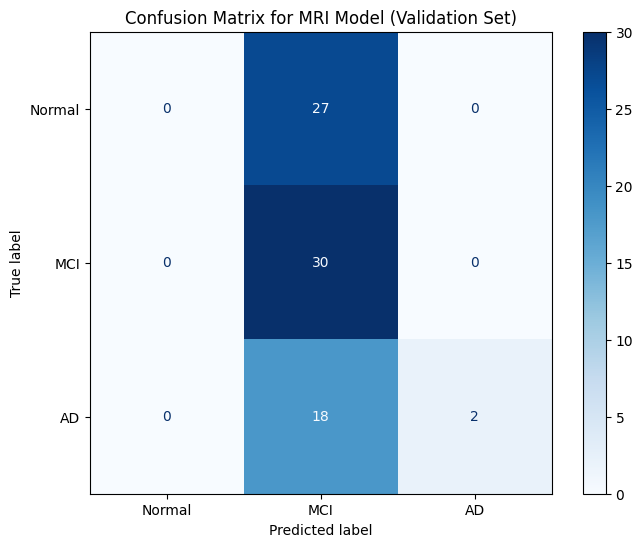


Classification Report:
              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00        27
         MCI       0.40      1.00      0.57        30
          AD       1.00      0.10      0.18        20

    accuracy                           0.42        77
   macro avg       0.47      0.37      0.25        77
weighted avg       0.42      0.42      0.27        77



In [52]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from tqdm.notebook import tqdm

# Clear unused GPU memory before starting
torch.cuda.empty_cache()

# Ensure model is in evaluation mode
mri_model.eval()

all_preds = []
all_labels = []

print("Evaluating MRI model on the validation set...")
with torch.no_grad():
    # Iterate over the validation data
    for mri, clin, labels in tqdm(val_loader, desc="Validation"):
        mri, labels = mri.to(device), labels.to(device)
        outputs = mri_model(mri)

        # Get the predicted classes (highest probability)
        _, preds = torch.max(outputs, 1)

        # Store predictions and true labels
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Class names based on your label map
class_names = ['Normal', 'MCI', 'AD']

# 1. Plot Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion Matrix for MRI Model (Validation Set)")
plt.show()

# 2. Print Classification Report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))

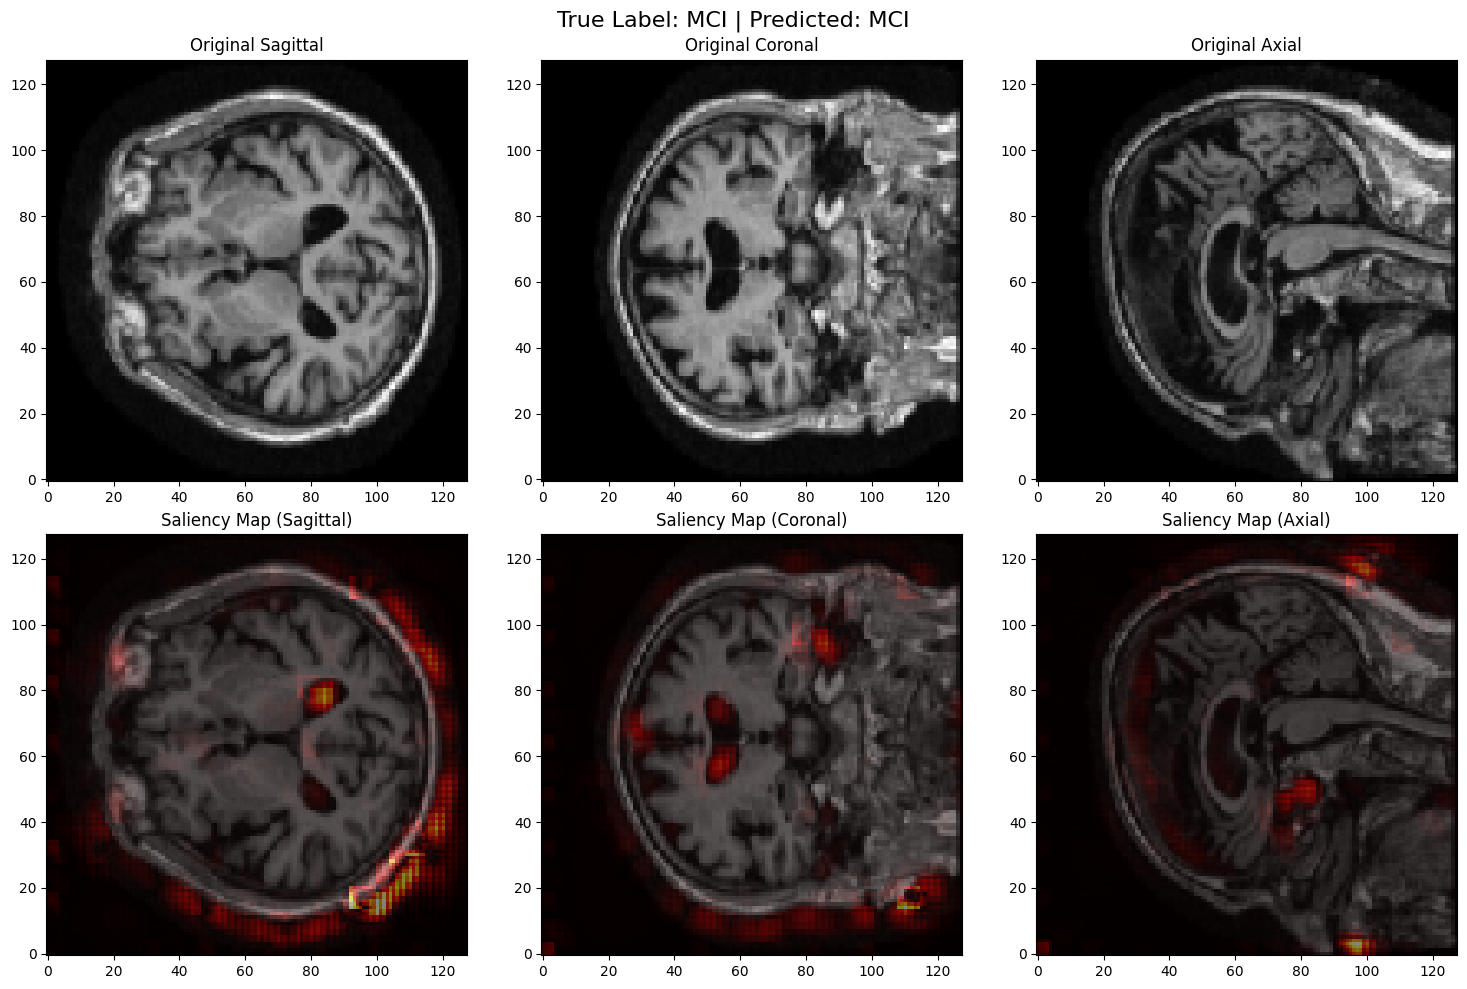

In [53]:
import monai
import matplotlib.pyplot as plt
import torch

# Ensure model is in eval mode and requires gradients for input
mri_model.eval()

# Get a single batch from the validation loader
sample_mri, sample_clin, sample_label = next(iter(val_loader))
sample_mri = sample_mri.to(device)
sample_mri.requires_grad = True

# Forward pass
output = mri_model(sample_mri)
target_class = output.argmax(dim=1).item()

# Calculate gradients with respect to the input image (Vanilla Saliency)
output[0, target_class].backward()
saliency_map = sample_mri.grad.abs().squeeze().cpu().numpy()

# Get the original image
original_img = sample_mri.detach().squeeze().cpu().numpy()

# Get middle slices
mid_x, mid_y, mid_z = [dim // 2 for dim in original_img.shape]

# Create the plot
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot original slices
axes[0, 0].imshow(original_img[mid_x, :, :].T, cmap='gray', origin='lower')
axes[0, 0].set_title(f'Original Sagittal')
axes[0, 1].imshow(original_img[:, mid_y, :].T, cmap='gray', origin='lower')
axes[0, 1].set_title(f'Original Coronal')
axes[0, 2].imshow(original_img[:, :, mid_z].T, cmap='gray', origin='lower')
axes[0, 2].set_title(f'Original Axial')

# Plot saliency maps overlay
for i, (ax, slice_idx, axis_name) in enumerate(zip(axes[1], [mid_x, mid_y, mid_z], ['Sagittal', 'Coronal', 'Axial'])):
    if i == 0:
        base = original_img[slice_idx, :, :].T
        heatmap = saliency_map[slice_idx, :, :].T
    elif i == 1:
        base = original_img[:, slice_idx, :].T
        heatmap = saliency_map[:, slice_idx, :].T
    else:
        base = original_img[:, :, slice_idx].T
        heatmap = saliency_map[:, :, slice_idx].T

    ax.imshow(base, cmap='gray', origin='lower')
    ax.imshow(heatmap, cmap='hot', alpha=0.5, origin='lower') # Overlay heatmap
    ax.set_title(f'Saliency Map ({axis_name})')

plt.suptitle(f'True Label: {class_names[sample_label.item()]} | Predicted: {class_names[target_class]}', fontsize=16)
plt.tight_layout()
plt.show()

# Clear gradients and memory
sample_mri.grad = None
torch.cuda.empty_cache()

In [51]:
import torch

# Path where the best model was saved during training
checkpoint_path = '/content/drive/My Drive/BIOL 2595 Final Proj/models/best_mri_swin_model.pth'

print(f"Loading best model weights from: {checkpoint_path}...")
try:
    checkpoint = torch.load(checkpoint_path, map_location=device)
    mri_model.load_state_dict(checkpoint['model_state_dict'])
    print(f"\u2705 Successfully loaded model from Epoch {checkpoint.get('epoch', 'Unknown')} with Val Acc: {checkpoint.get('best_val_acc', 0.0):.2f}%")
except Exception as e:
    print(f"\u274c Error loading checkpoint: {e}\nMake sure the file exists and training completed at least one successful epoch.")

# Ensure model is in evaluation mode for the next steps
mri_model.eval()


Loading best model weights from: /content/drive/My Drive/BIOL 2595 Final Proj/models/best_mri_swin_model.pth...
✅ Successfully loaded model from Epoch 34 with Val Acc: 41.56%


ResNet(
  (conv1): Conv3d(1, 64, kernel_size=(7, 7, 7), stride=(1, 1, 1), padding=(3, 3, 3), bias=False)
  (bn1): InstanceNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
  (act): ReLU(inplace=True)
  (maxpool): MaxPool3d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): ResNetBlock(
      (conv1): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
      (bn1): InstanceNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
      (act): ReLU(inplace=True)
      (conv2): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
      (bn2): InstanceNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
    )
    (1): ResNetBlock(
      (conv1): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
      (bn1): InstanceNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_runn